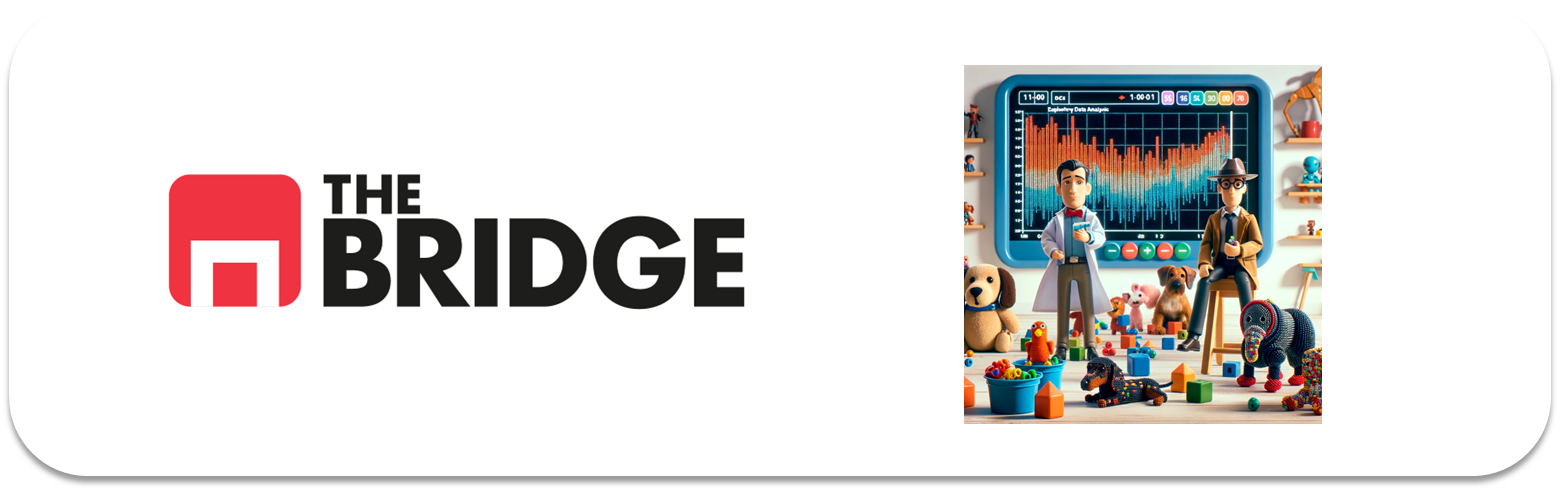

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

* Objetivo: Si lo tengo perfecto, si no -> lo busco
* LIMPIAR/PREPARAR LOS DATOS
* Tabla de variables: definiciones, tipificar, priorizar
* Análisis Univariante: Análisis visual y numérico
    - Categóricas: Moda, Frecuencias Absolutas y Relativas
    - Numéricas: Tendencia central (mediana, media), rangos, posición (percentiles-cuartiles, IQR, CV),distribución (histograma, densidad probabilidad)
* Análisis Bivariante: Análisis visual y numérico
    - Categórica - Categórica: Chi-2
        - Tablas de contigencia (solo para cat. con cardinalidad controlada)
    - Categórica - Numérica: 
        - Categórica es binaria: Prueba U Mann-Whitney (t-student si dist. normal)
        - Categórica no es binaria: ANOVA
    - Numérica - Numérica: Correlación de Pearson (Prueba estadística)
        - No hay correlación de Pearson para
Categóricas
        - Binarias tampoco es correcto Pearson
    - Notas con ideas, preguntas, cosas extraordinarias
* Análisis Multivariante: A ojo, "free style"
* Haces retrospectiva -> lista de verdades/hipótesis/preguntas/suposiciones/inquietudes
    - Números
* Respuestas: MENSAJES
    - Si no hay respuesta en los datos -> ok
    - Si la respuesta es un número -> ok
    - Si la respuesta es NO -> ok

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion, bubble_plot

from scipy.stats import chi2_contingency, mannwhitneyu, f_oneway, pearsonr

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [35]:
df_titanic = pd.read_csv('./data/titanic.csv')
df_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [36]:
df_titanic.drop(columns=['deck', 'survived', 'pclass', 'embarked'], inplace=True)
df_titanic

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [37]:
df_titanic['family_members'] = df_titanic.parch + df_titanic.sibsp
df_titanic.drop(columns=['sibsp', 'parch'], inplace=True)
df_titanic

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [38]:
df_titanic.embark_town.value_counts(dropna=False)

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

In [39]:
df_titanic.embark_town = df_titanic.embark_town.fillna(df_titanic.embark_town.mode()[0])
df_titanic.embark_town.value_counts(dropna=False)

embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [40]:
df_titanic.age.value_counts(dropna=False)

age
NaN      177
24.00     30
22.00     27
18.00     26
28.00     25
        ... 
24.50      1
0.67       1
0.42       1
34.50      1
74.00      1
Name: count, Length: 89, dtype: int64

In [41]:
df_titanic.age = df_titanic.age.fillna(df_titanic.groupby('who')['age'].transform('median'))

df_titanic.age.value_counts(dropna=False)

age
30.00    202
24.00     30
22.00     27
18.00     26
28.00     25
        ... 
24.50      1
0.67       1
0.42       1
34.50      1
74.00      1
Name: count, Length: 88, dtype: int64

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

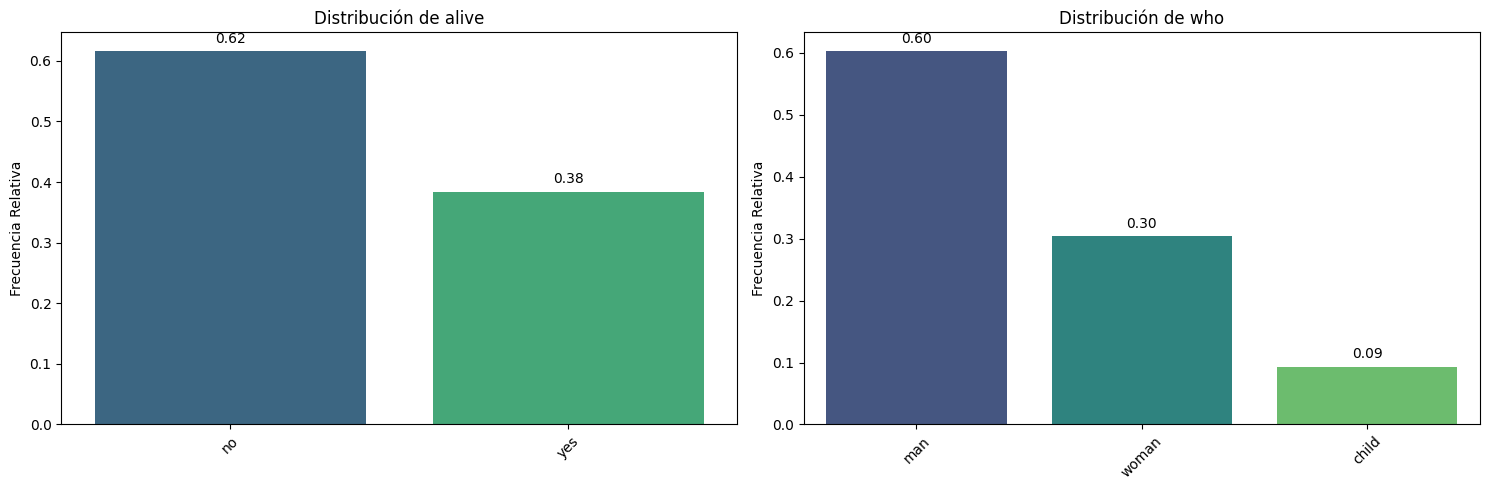

In [42]:
pinta_distribucion_categoricas(df_titanic,["alive","who"], relativa= True, mostrar_valores= True)

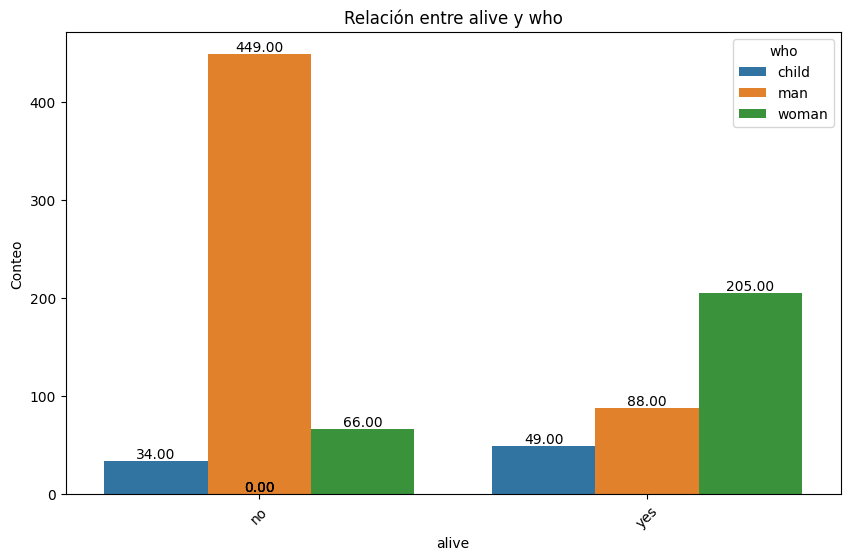

In [43]:
plot_categorical_relationship_fin(df_titanic, "alive","who", show_values= True)

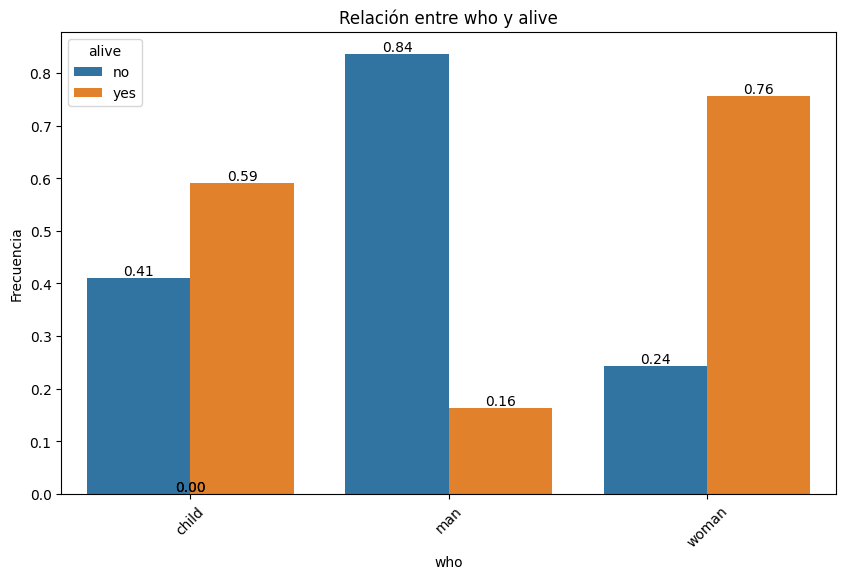

In [44]:
plot_categorical_relationship_fin(df_titanic, "who","alive", show_values= True, relative_freq=True)

In [45]:
tabla_contingencia = pd.crosstab(df_titanic['who'], df_titanic['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 283.923050324233
P-Value: 2.2227620817798914e-62
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[ 51.14141414  31.85858586]
 [330.87878788 206.12121212]
 [166.97979798 104.02020202]]


Existe una fuerte relación entre si era hombre, mujer o niño y su superviviencia.

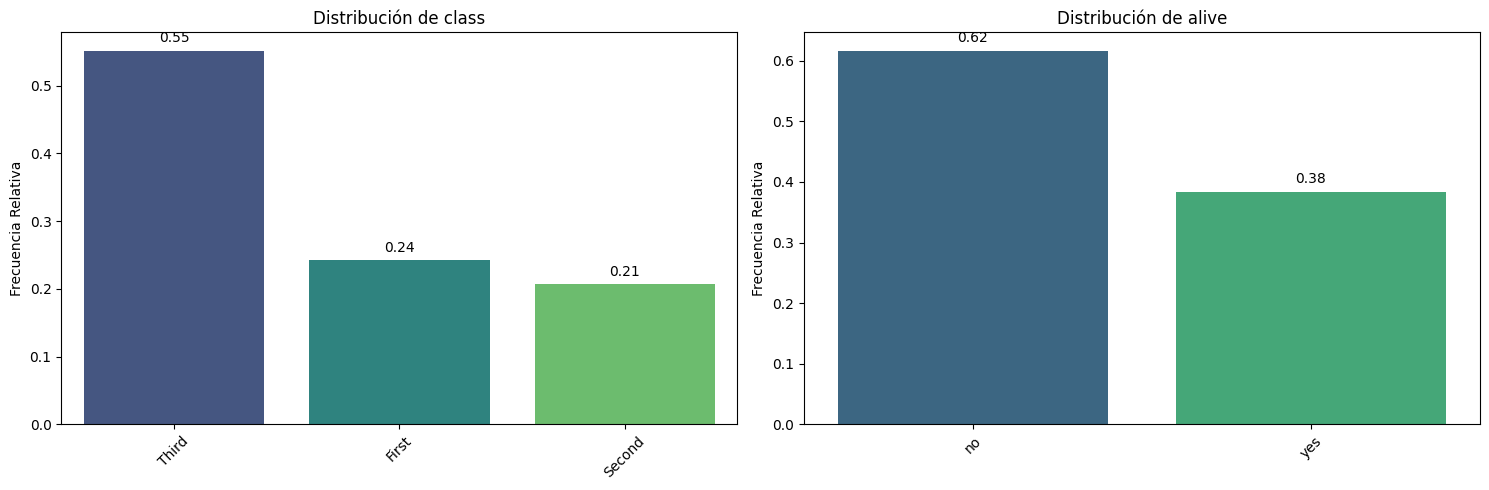

In [46]:
pinta_distribucion_categoricas(df_titanic,["class","alive"], relativa= True, mostrar_valores= True)

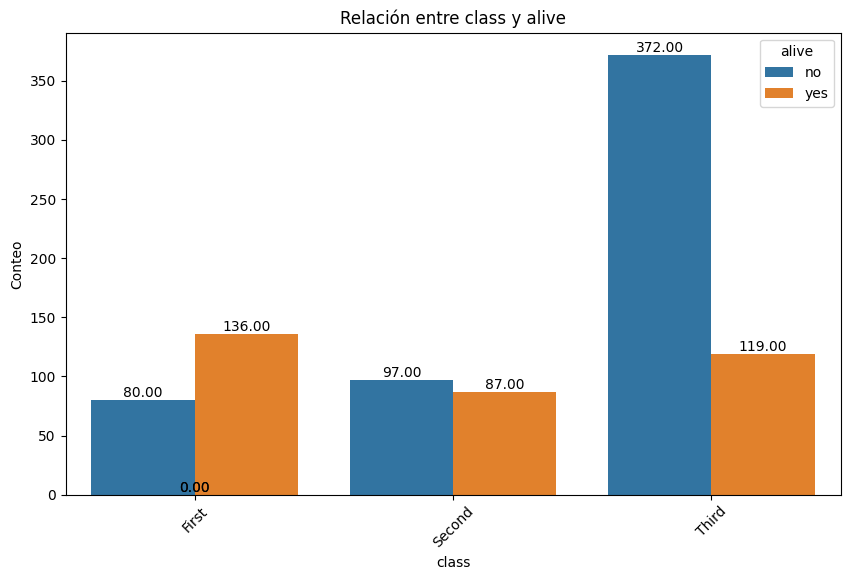

In [47]:
plot_categorical_relationship_fin(df_titanic, "class","alive", show_values= True)

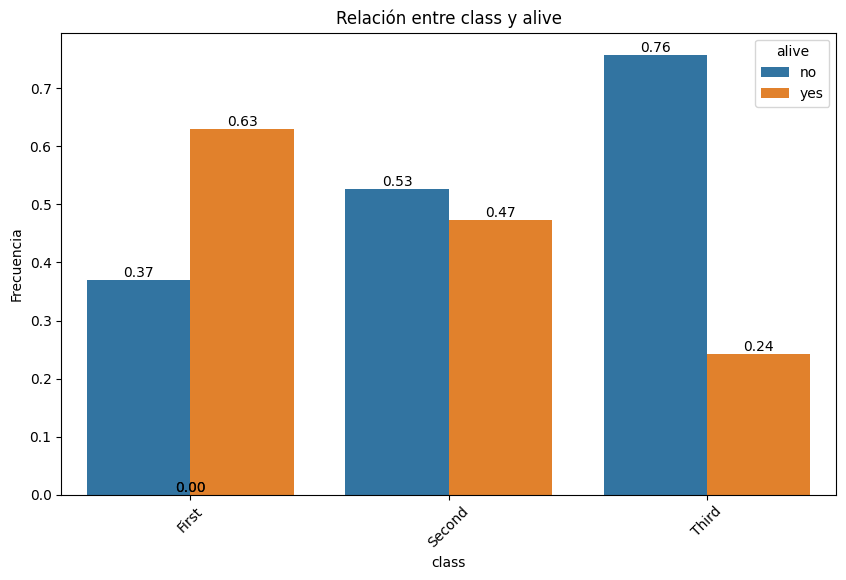

In [48]:
plot_categorical_relationship_fin(df_titanic, "class","alive", show_values= True, relative_freq=True)


In [49]:
tabla_contingencia = pd.crosstab(df_titanic['class'], df_titanic['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


Existe una fuerte relación entre la clase y su superviviencia.

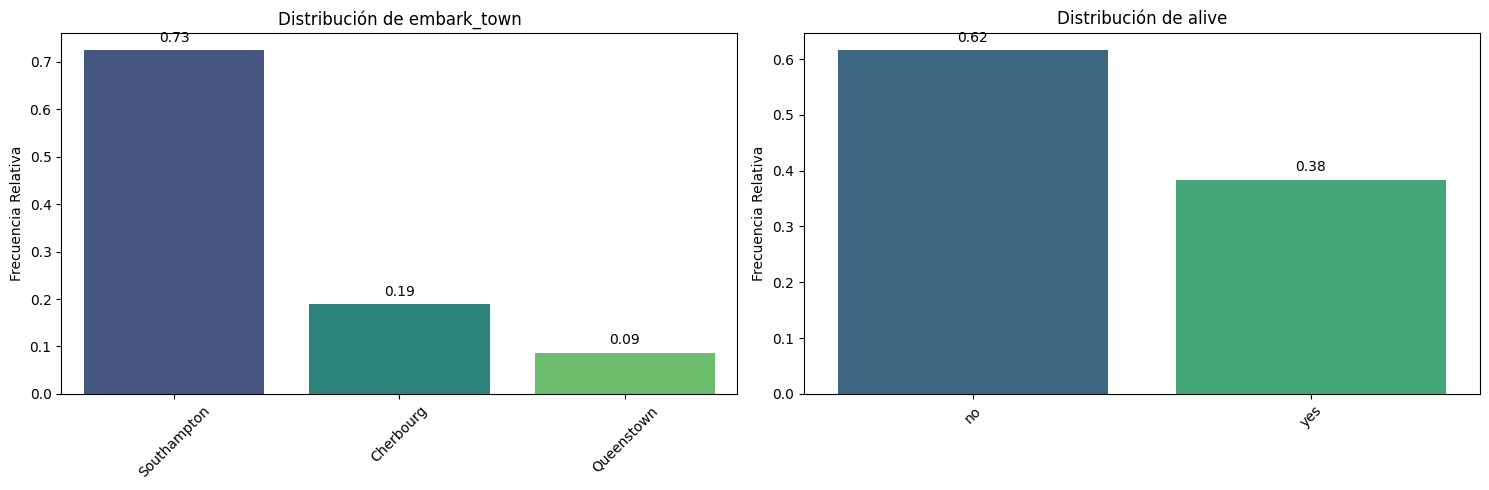

In [50]:
pinta_distribucion_categoricas(df_titanic,["embark_town","alive"], relativa= True, mostrar_valores= True)

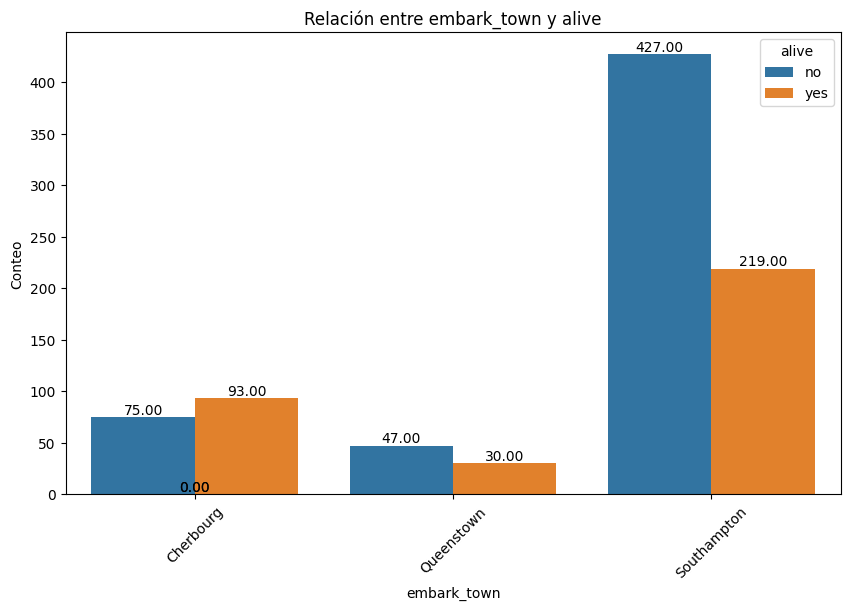

In [51]:
plot_categorical_relationship_fin(df_titanic, "embark_town","alive", show_values= True)

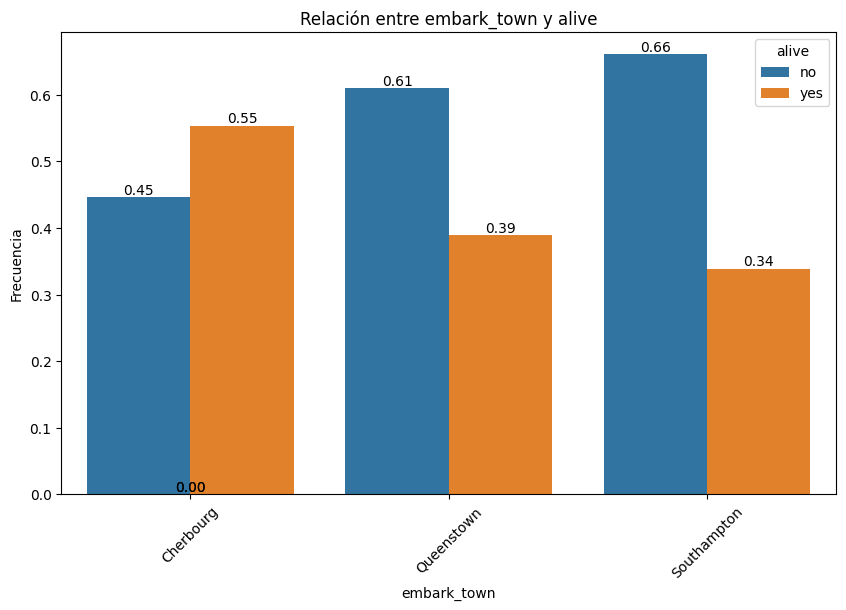

In [52]:
plot_categorical_relationship_fin(df_titanic, "embark_town","alive", show_values= True, relative_freq=True)


In [53]:
tabla_contingencia = pd.crosstab(df_titanic['embark_town'], df_titanic['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)
print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  64.48484848]
 [ 47.44444444  29.55555556]
 [398.04040404 247.95959596]]


Existe una relación entre la ciudad de embarque y su superviviencia.

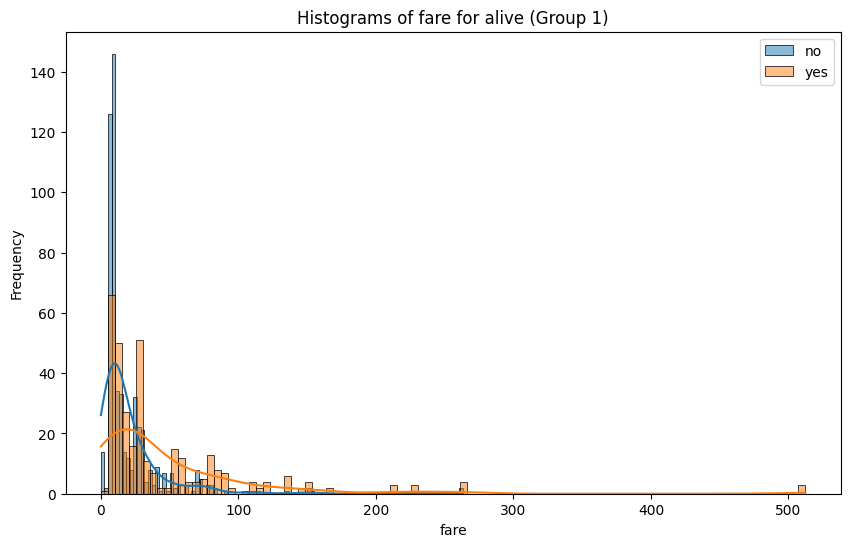

In [54]:
plot_grouped_histograms(df_titanic, cat_col="alive",num_col="fare", group_size= 2, bins=100)

In [55]:
u_stat, p_valor = mannwhitneyu(df_titanic.loc[df_titanic.alive == "yes"]["fare"],
                               df_titanic.loc[df_titanic.alive == "no"]["fare"])

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


Existe una relación entre el precio del billete y su supervivencia.

Los pasajeros que no pagaron el billete son los trabajadores y la mayoría murió, solo 1 sobrevivió.

El pasajero que más pago por su billete sobrevivió.

In [90]:
Southampton = df_titanic[df_titanic.embark_town == 'Southampton']
Queenstown = df_titanic[df_titanic.embark_town == 'Queenstown']
Cherbourg = df_titanic[df_titanic.embark_town == 'Cherbourg']

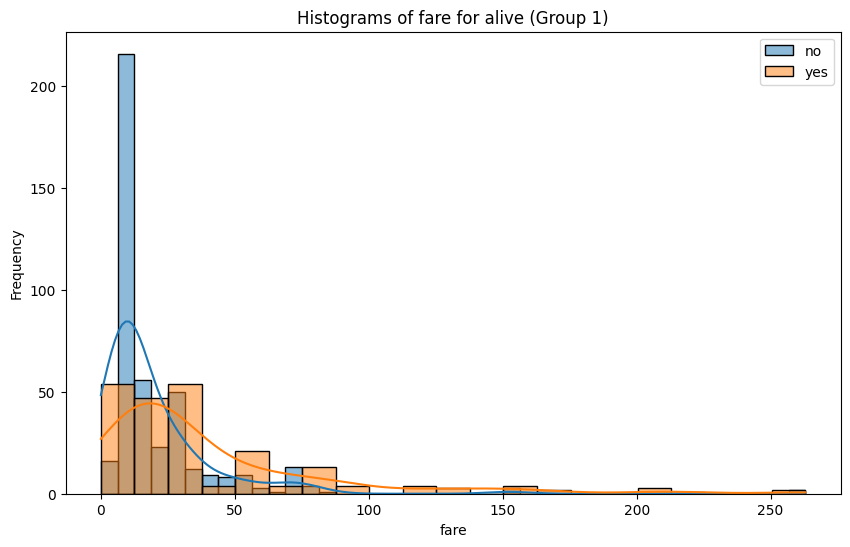

In [93]:
plot_grouped_histograms(Southampton, cat_col="alive",num_col="fare", group_size= 2)

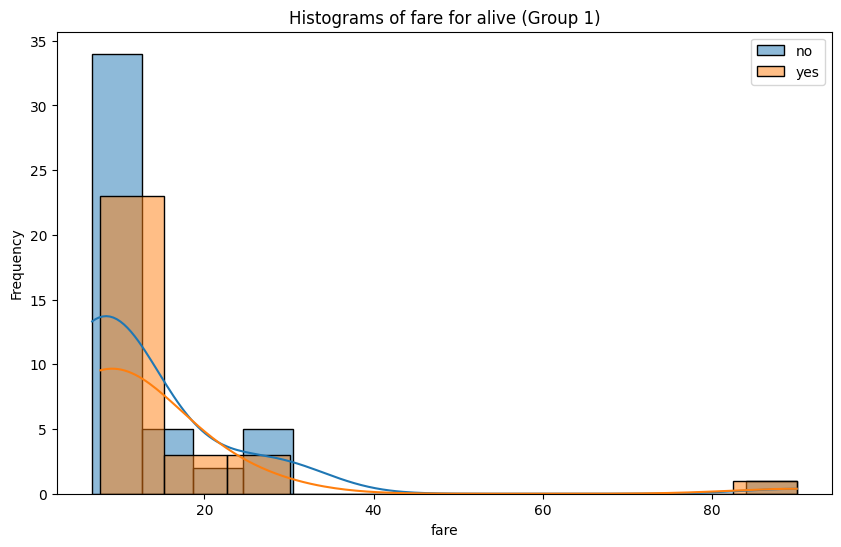

In [94]:
plot_grouped_histograms(Queenstown, cat_col="alive",num_col="fare", group_size= 2)

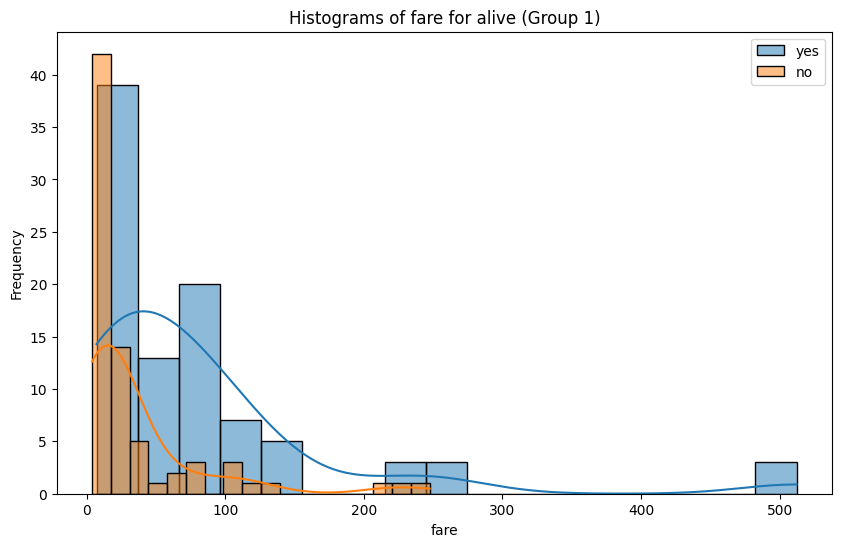

In [95]:
plot_grouped_histograms(Cherbourg, cat_col="alive",num_col="fare", group_size= 2)

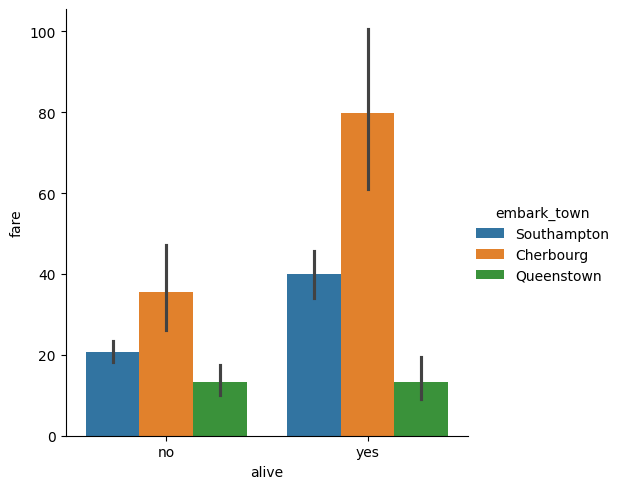

In [56]:
sns.catplot(
    data=df_titanic,
    x="alive",
    y="fare",
    hue="embark_town",
    kind="bar"
)

In [57]:
df_titanic.groupby(['alive', 'embark_town'])['fare'].mean()

alive  embark_town
no     Cherbourg      35.443335
       Queenstown     13.335904
       Southampton    20.743987
yes    Cherbourg      79.720926
       Queenstown     13.182227
       Southampton    39.916514
Name: fare, dtype: float64

El precio medio del billete según el origen y desenlace varía mucho.

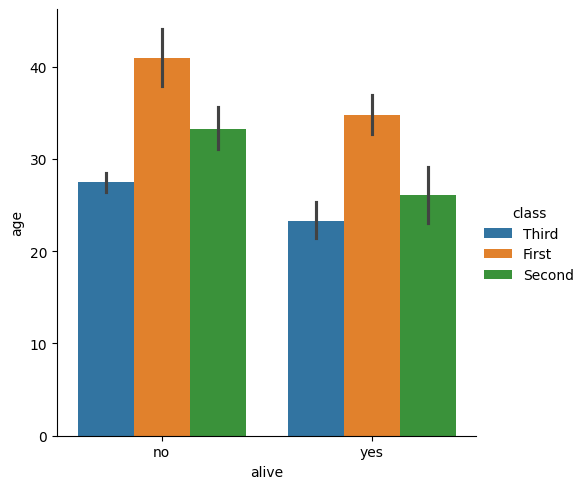

In [58]:
sns.catplot(
    data=df_titanic,
    x="alive",
    y="age",
    hue="class",
    kind="bar"
)

In [60]:
df_titanic[df_titanic.alive == 'yes'].groupby(['class', 'who'])['alive'].count()

class   who  
First   child     5
        man      42
        woman    89
Second  child    19
        man       8
        woman    60
Third   child    25
        man      38
        woman    56
Name: alive, dtype: int64

In [61]:
df_titanic[df_titanic.alive == 'no'].groupby(['class', 'who'])['alive'].count()


class   who  
First   child      1
        man       77
        woman      2
Second  man       91
        woman      6
Third   child     33
        man      281
        woman     58
Name: alive, dtype: int64

In [62]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df_titanic[col_directora].unique():
    diccionario_multivariante[valor] = df_titanic.loc[df_titanic[col_directora] == valor,[col_2,col_1]] # Ojo al orden quiero ver para cada oferta como es la distribución de educacion

Respuesta no:


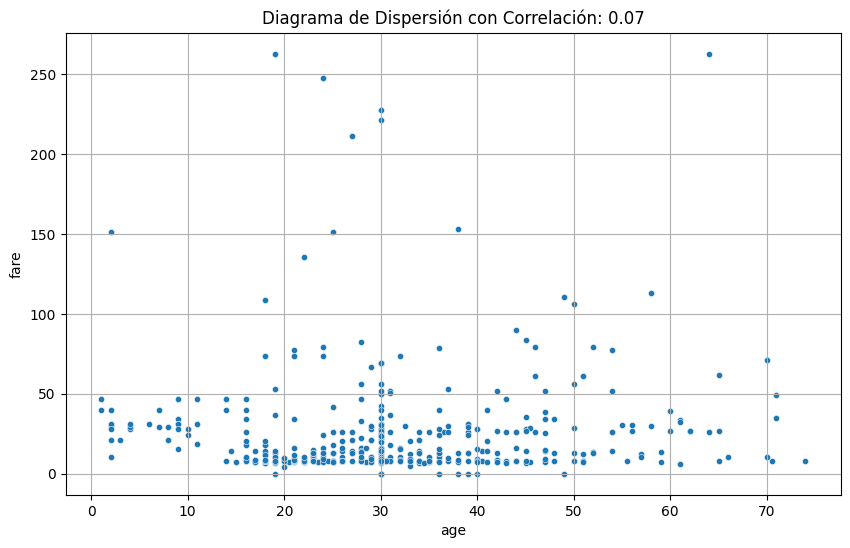

Respuesta yes:


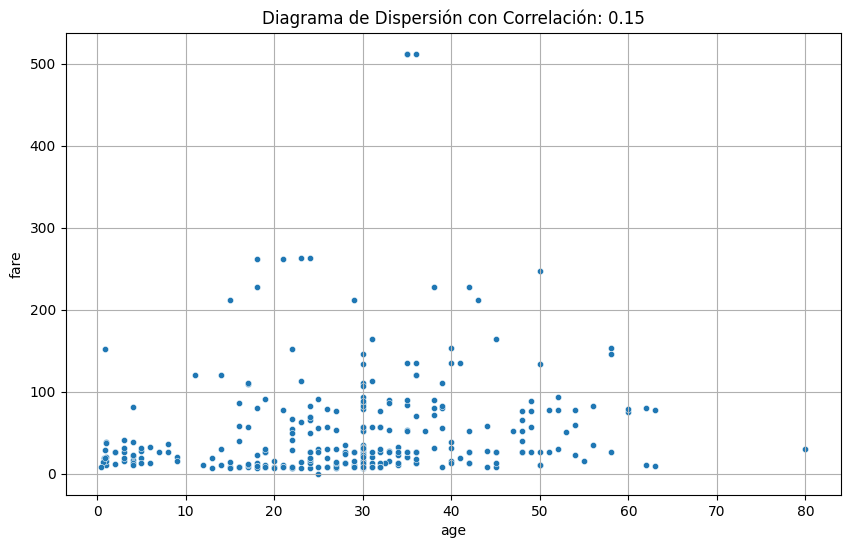

In [63]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

No veo ninguna correlación entre estas variables

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [64]:
df_viajes = pd.read_csv('./data/dataset_viajes_jun.csv')
df_viajes

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23
...,...,...,...,...,...,...,...,...,...,...,...
595,PamPangea,Bali,Londres,12553,Boeing 737,True,33310.138680,1153,442668.52,Pam_BaLo_10737,Jun23
596,Airnar,Cádiz,París,1447,Airbus A380,False,17229.139600,116,87307.63,Air_CaPa_11380,Jun23
597,Airnar,Los Angeles,Cádiz,9373,Boeing 737,False,23231.917800,731,339943.47,Air_LoCa_10737,Jun23
598,FlyQ,Barcelona,Bali,13058,Boeing 747,True,144766.211200,1070,752212.98,Fly_BaBa_10747,Jun23


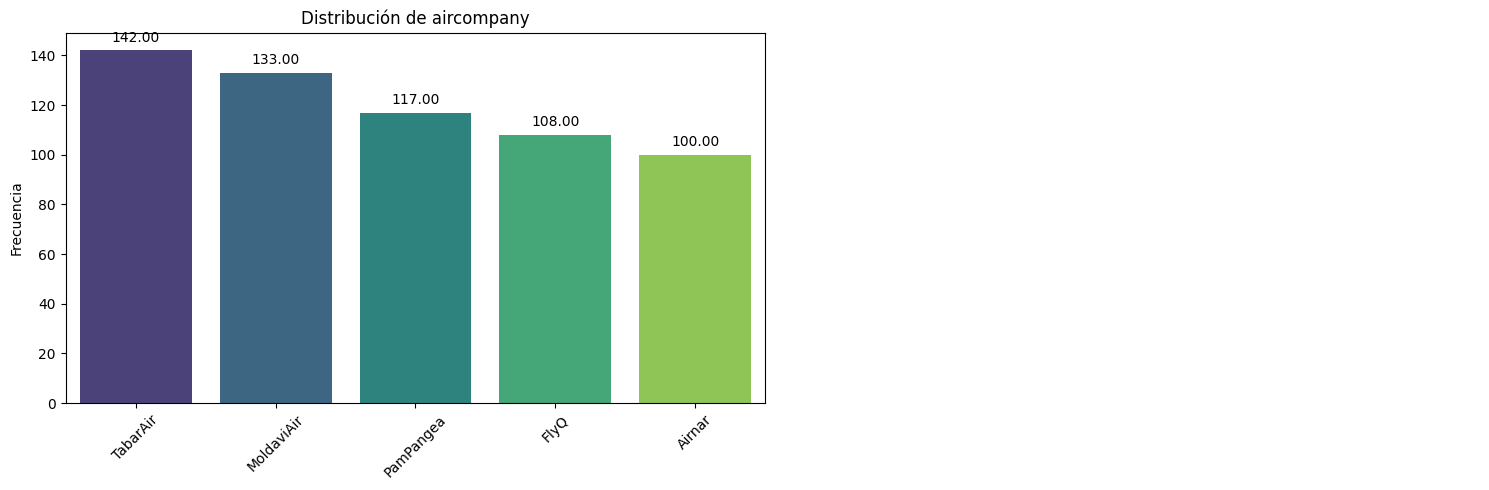

In [65]:
pinta_distribucion_categoricas(df_viajes,["aircompany"], mostrar_valores= True)

(2,)


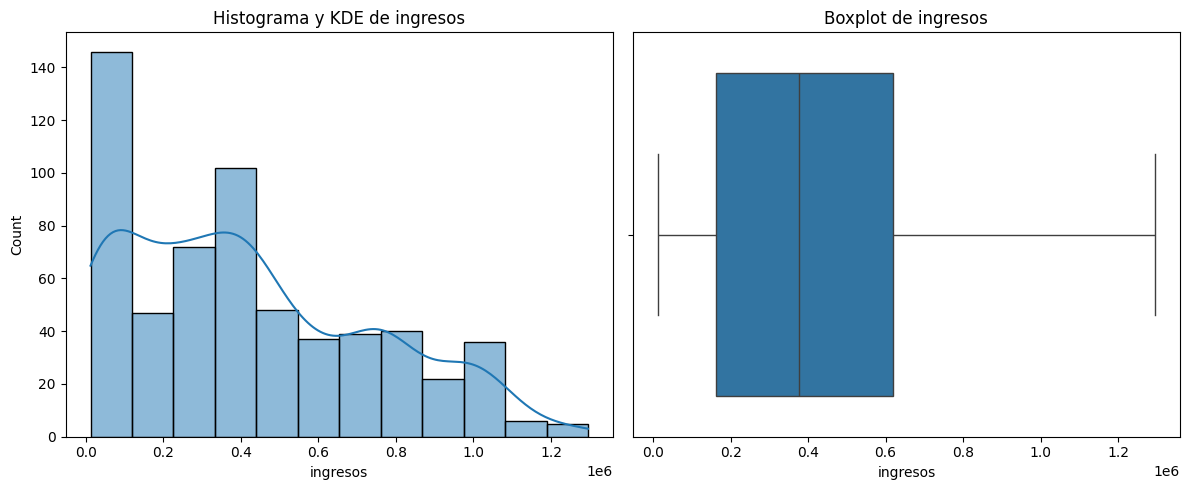

In [66]:
plot_combined_graphs(df_viajes,["ingresos"])

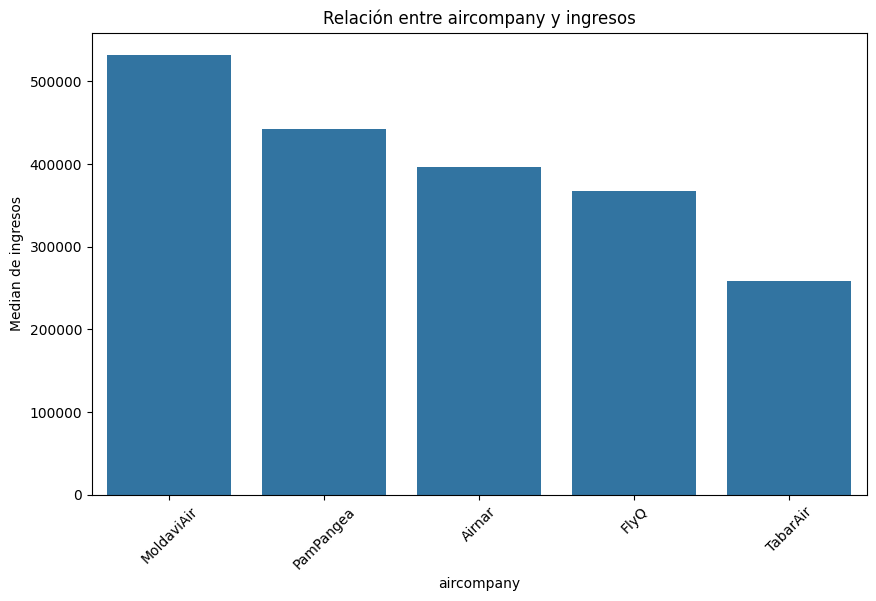

In [67]:
plot_categorical_numerical_relationship(df_viajes,"aircompany","ingresos", measure = "median")

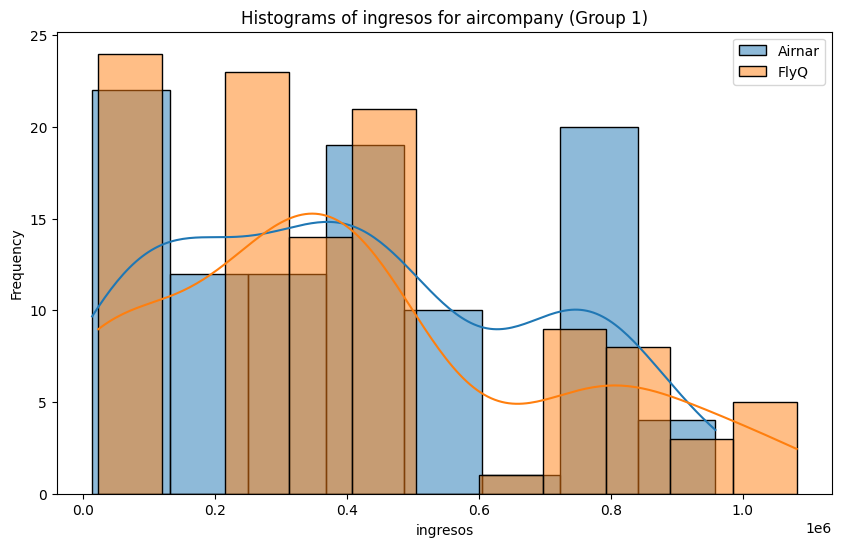

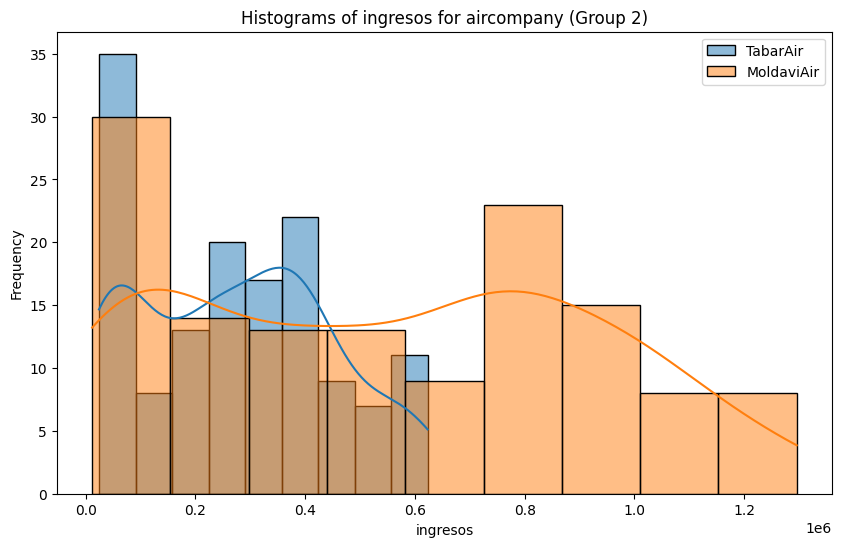

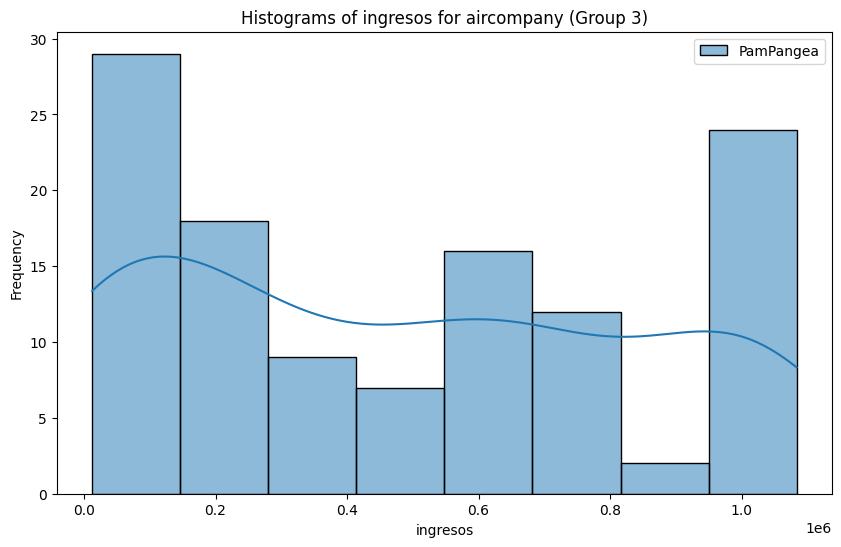

In [68]:
plot_grouped_histograms(df_viajes,"aircompany", "ingresos", 2)

In [69]:
grupos = df_viajes['aircompany'].unique()  # Obtener los valores únicos de la columna categórica, en este caso la compañía área
ingresos_por_company = [df_viajes[df_viajes['aircompany'] == grupo]['ingresos'] for grupo in grupos] # obtenemos los ingresos por compañía y los incluimos en una lista
ingresos_por_company

[0       14232.65
 9      110108.07
 17     518685.45
 21     799063.90
 23     432558.22
          ...    
 573    732878.07
 577    754191.00
 580    928050.52
 596     87307.63
 597    339943.47
 Name: ingresos, Length: 100, dtype: float64,
 1       468527.19
 33      273824.24
 36      235350.43
 40       25642.94
 41      417965.59
           ...    
 575     429377.42
 581    1004810.48
 589     398905.47
 590      31227.48
 598     752212.98
 Name: ingresos, Length: 108, dtype: float64,
 2      584789.19
 4      438535.07
 10     111056.67
 12     184079.01
 13      46200.30
          ...    
 572    258737.92
 582    423371.06
 587    404542.35
 593    550268.31
 599    330320.81
 Name: ingresos, Length: 142, dtype: float64,
 3       233342.51
 5       728045.68
 6        13805.52
 11      764998.83
 16      719577.55
           ...    
 578      12372.41
 579     409713.51
 583    1006880.11
 584      70674.57
 585     225493.20
 Name: ingresos, Length: 133, dtype: float64,
 7

In [70]:
f_val, p_val = f_oneway(*ingresos_por_company) # El método * (igual que cuando vimos *args hace mil años) 
                                                    # lo que hace es separar todos los elementos de la lista y pasarselos como argumento a la función
print("Valor F:", f_val)
print("Valor p:", p_val)

Valor F: 15.686872918809376
Valor p: 3.267745855663723e-12


### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

In [71]:
corr_matrix = df_viajes.corr(numeric_only= True) # Si no lo pones y tienes variables tipo texto, fallará7
corr_matrix

,distancia,con_escala,consumo_kg,duracion,ingresos
distancia,1.000000,0.669866,0.762341,0.985963,0.928833
con_escala,0.669866,1.000000,0.322295,0.761097,0.515817
consumo_kg,0.762341,0.322295,1.000000,0.668707,0.944875
duracion,0.985963,0.761097,0.668707,1.000000,0.867515
ingresos,0.928833,0.515817,0.944875,0.867515,1.000000


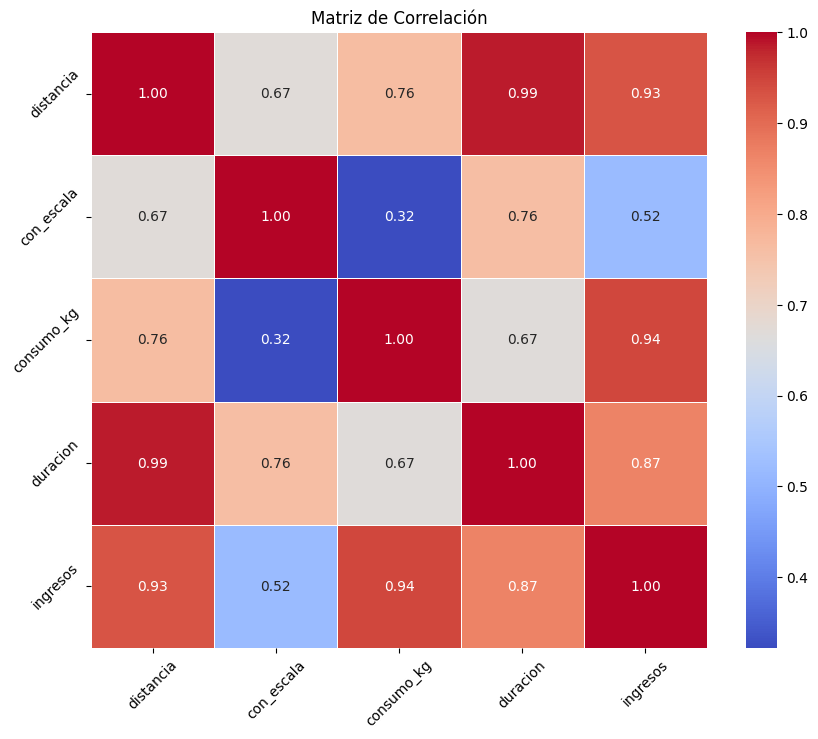

In [72]:
plt.figure(figsize=(10, 8))  # Ya lo veremos pero esto permite ajustar el tamaño de las gráficas
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            cbar=True, square=True, linewidths=.5) # el cmap es el rango de colores usado para representar "el calor"

plt.title('Matriz de Correlación')
plt.xticks(rotation=45)  # Rota las etiquetas de las x si es necesario
plt.yticks(rotation=45)  # Rota las etiquetas de las y si es necesario

plt.show()

In [73]:
df_solo_numeros = df_viajes.select_dtypes(include = ["float","int"])
df_solo_numeros.columns

Index(['distancia', 'consumo_kg', 'duracion', 'ingresos'], dtype='object')

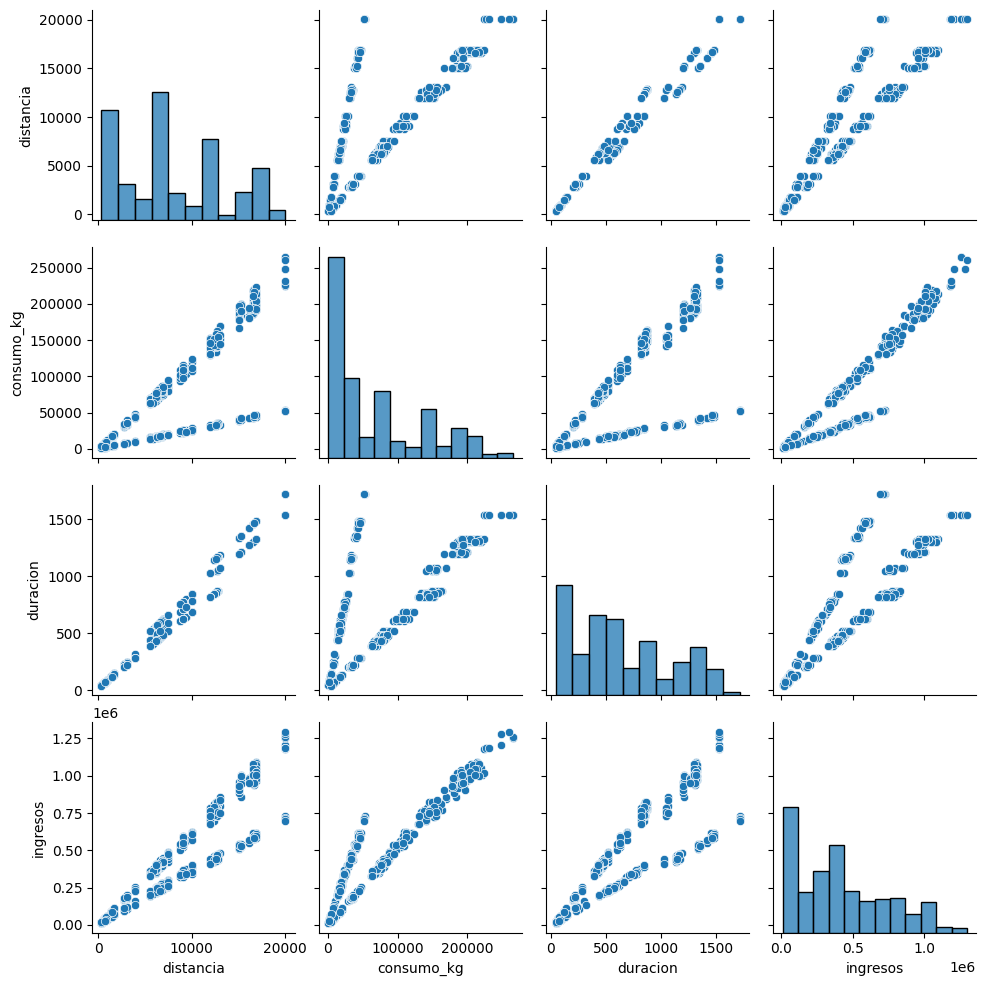

In [74]:
sns.pairplot(df_solo_numeros)
plt.show()

(3, 2)


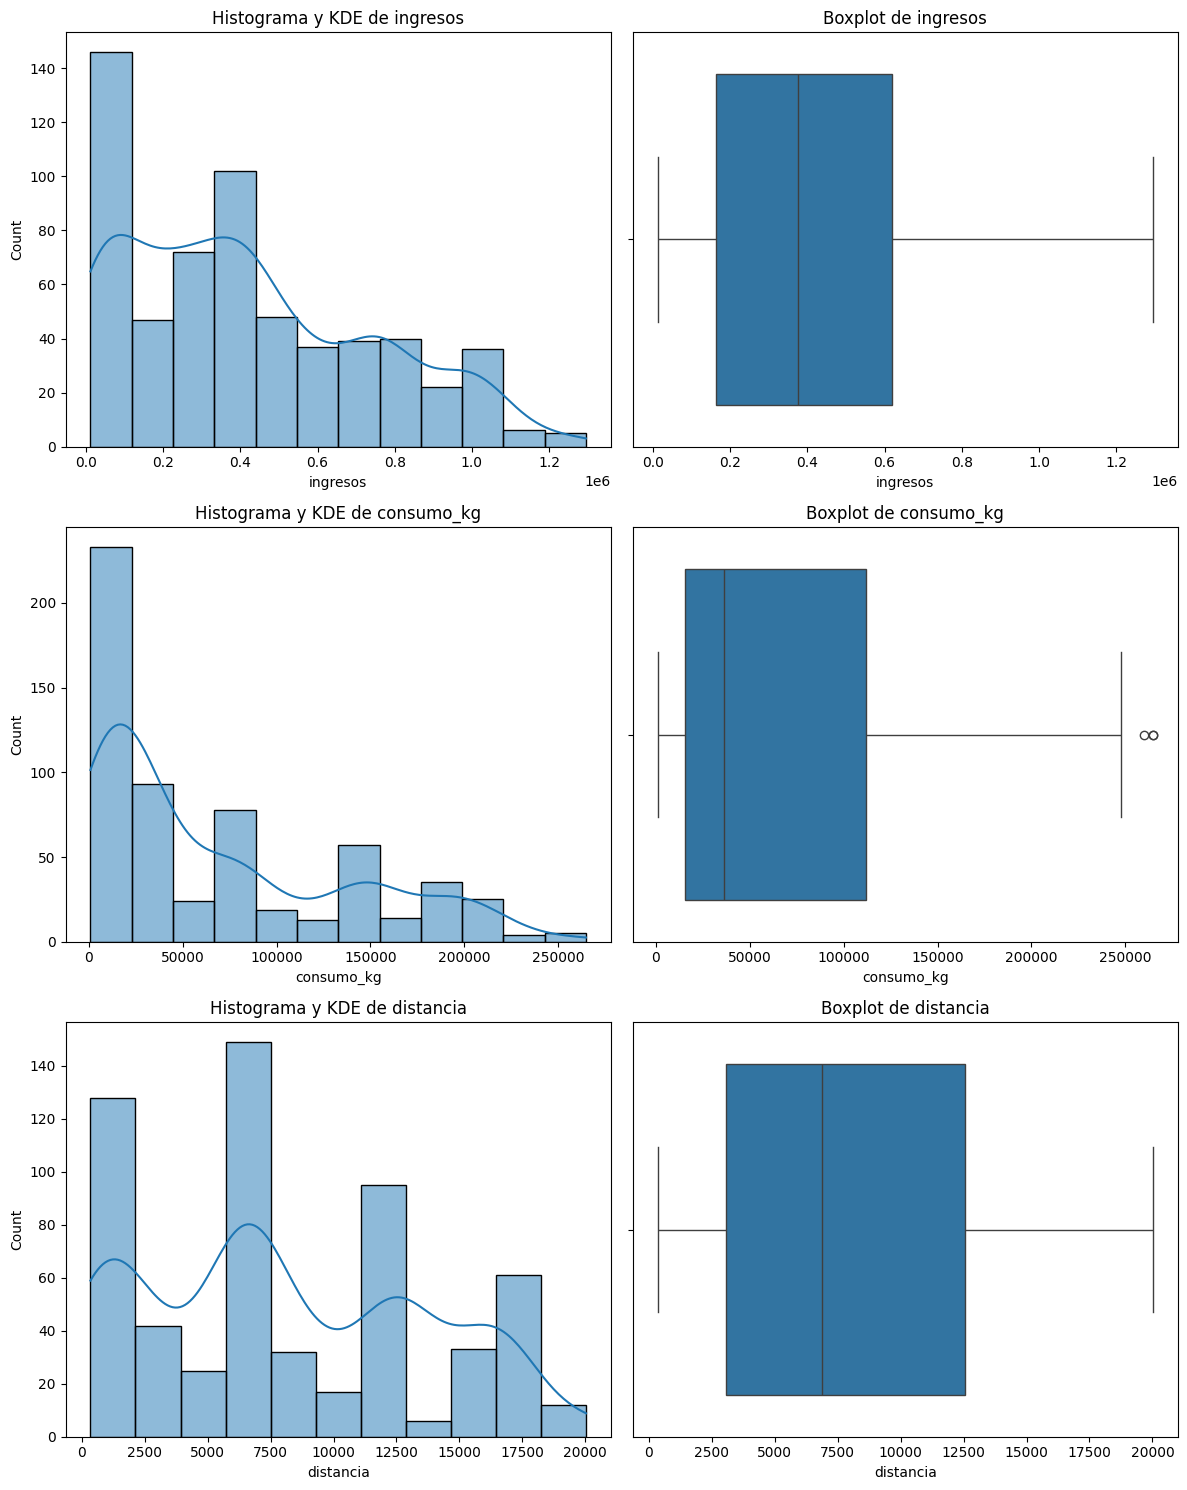

In [75]:
plot_combined_graphs(df_viajes,["ingresos","consumo_kg","distancia"])

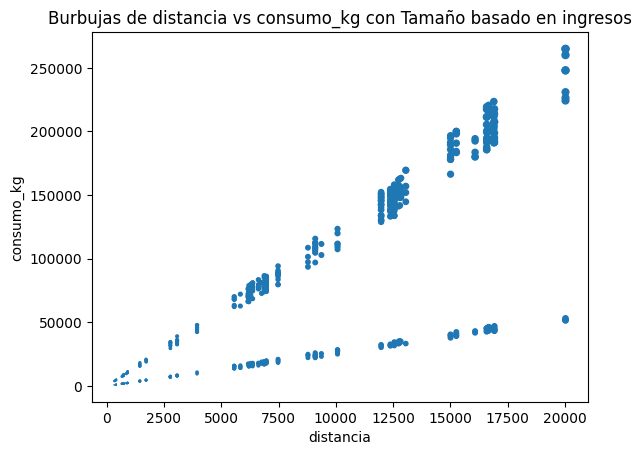

In [76]:
bubble_plot(df_viajes,"distancia","consumo_kg","ingresos", scale = 50000)


### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

In [77]:
df_viajes['cat_vuelo'] = pd.cut(
    df_viajes['distancia'],
    bins=[0, 4800, 11000, 19000, 25000],
    labels=['corta distancia', 'media_distancia', 'larga_distancia', 'muy_larga_distancia']
)
df_viajes.sample(5)

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes,cat_vuelo
250,MoldaviAir,París,Melbourne,16925,Boeing 737,True,44056.045800,1485,607631.02,Mol_PaMe_10737,Jun23,larga_distancia
66,Airnar,Cincinnati,Cádiz,6624,Boeing 747,False,77673.024000,461,406616.70,Air_CiCa_10747,Jun23,media_distancia
545,Airnar,Cádiz,Cincinnati,6624,Airbus A320,True,17982.941184,600,259899.94,Air_CaCi_11320,Jun23,media_distancia
16,MoldaviAir,Melbourne,Cádiz,20029,Boeing 737,True,51629.634576,1721,719577.55,Mol_MeCa_10737,Jun23,muy_larga_distancia
379,FlyQ,Cincinnati,Nueva York,911,Airbus A380,False,11268.341200,80,56324.42,Fly_CiNu_11380,Jun23,corta distancia


In [78]:
col_directora = "cat_vuelo"
col_1 = "ingresos"
col_2 = "distancia"
diccionario_multivariante = {}
for valor in ['corta distancia', 'media_distancia', 'larga_distancia', 'muy_larga_distancia']:
    diccionario_multivariante[valor] = df_viajes.loc[df_viajes[col_directora] == valor,[col_2,col_1]]

Respuesta corta distancia:


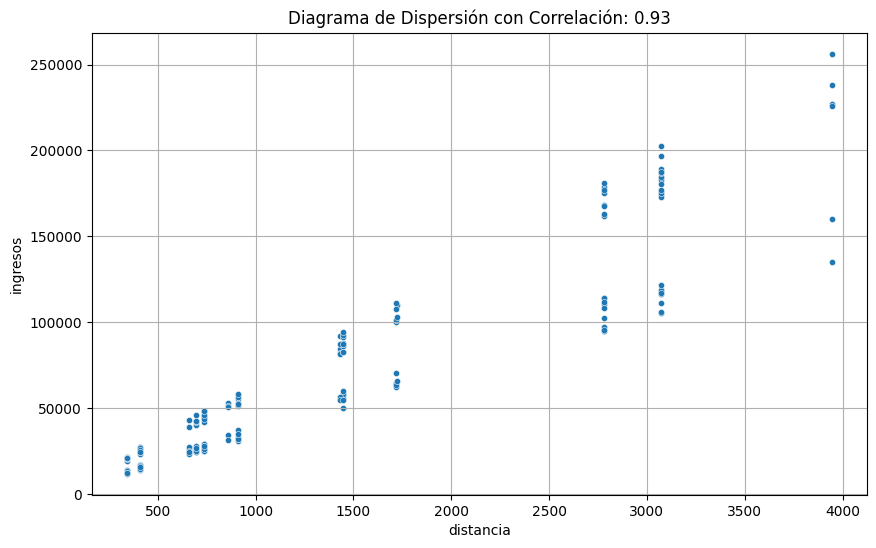

Respuesta media_distancia:


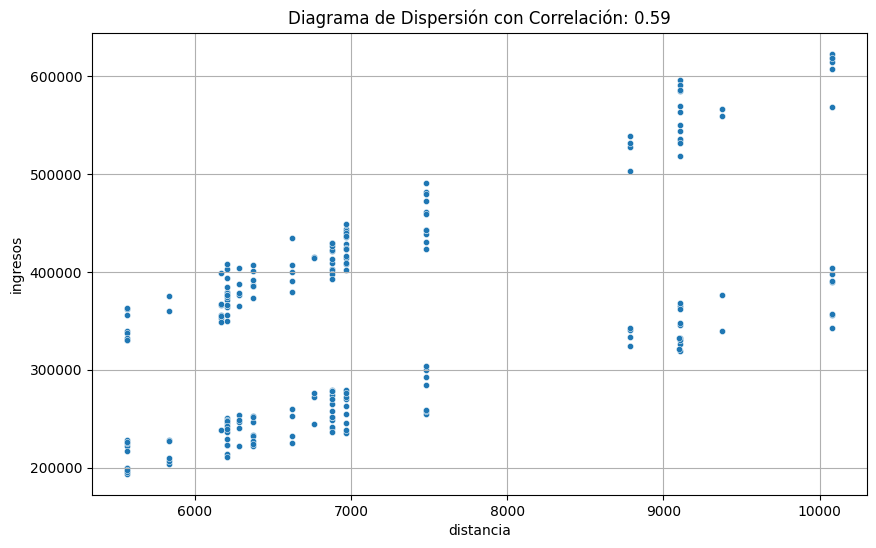

Respuesta larga_distancia:


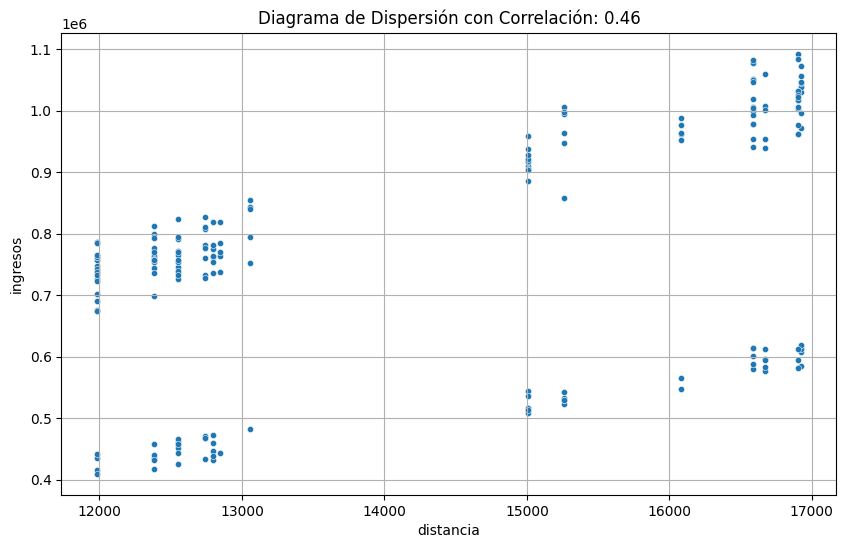

Respuesta muy_larga_distancia:


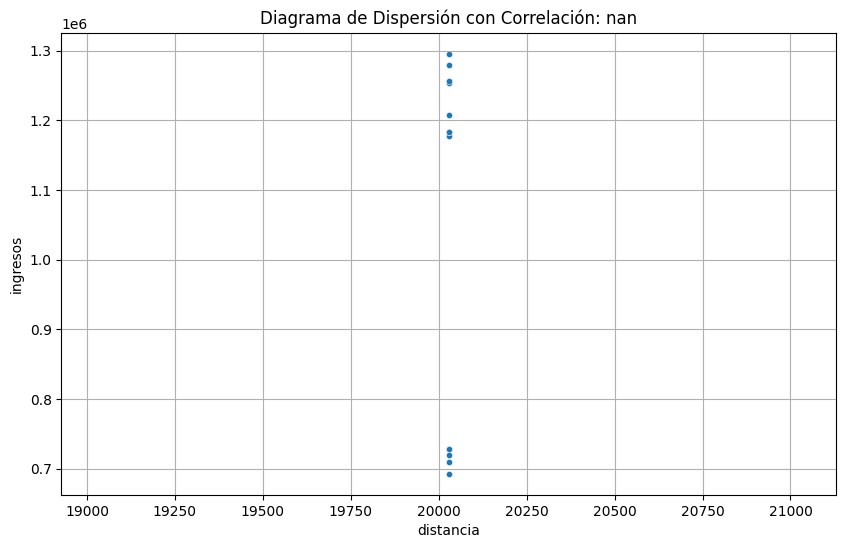

In [81]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)